In [21]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
import torch

# vector plots
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Generate some data

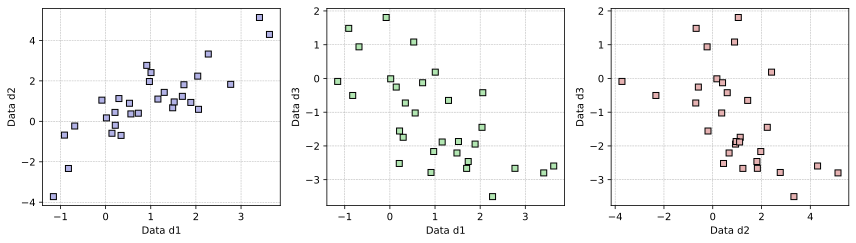

In [22]:
# sample size
N = 30

# data vectors
d1 = np.random.randn(N) + 1 # add an offset for Pearson vs. cosine-similarity
d2 = d1 + np.random.randn(N)
d3 = -d1 + np.random.randn(N)

# visualize
_,axs = plt.subplots(1,3,figsize=(12,3.5))
axs[0].plot(d1,d2,'ks',markerfacecolor=[.7,.7,.9])
axs[0].set(xlabel='Data d1',ylabel='Data d2')

axs[1].plot(d1,d3,'ks',markerfacecolor=[.7,.9,.7])
axs[1].set(xlabel='Data d1',ylabel='Data d3')

axs[2].plot(d2,d3,'ks',markerfacecolor=[.9,.7,.7])
axs[2].set(xlabel='Data d2',ylabel='Data d3')

for a in axs: a.grid(linestyle='--',linewidth=.5)

plt.tight_layout()
plt.show()

In [25]:
print(d1.shape)
print(d2.shape)
print(d3.shape)

(30,)
(30,)
(30,)


# Cosine similarity: manual calculation and sklearn

In [29]:
# cosine similarity manual
num = sum( d1*d2 )
den = sum( d1*d1 ) * sum(d2**2)
cossim_manual = num/np.sqrt(den)

print(f'Manual calculation: Cosine similarity between d1 and d2 is {cossim_manual:.4f}')

Manual calculation: Cosine similarity between d1 and d2 is 0.8699


In [30]:
# check against sklearn
# cossim_sklearn = cosine_similarity(d1,d2)
cossim_sklearn = cosine_similarity(d1.reshape(1,-1),d2.reshape(1,-1))
print(f'Sci-kit learn: Cosine similarity between d1 and d2 is {cossim_sklearn[0][0]:.4f}')

Sci-kit learn: Cosine similarity between d1 and d2 is 0.8699


In [31]:
print(d1.reshape(1,-1).shape)
print(d1.shape)

(1, 30)
(30,)


# Comparison with Pearson correlation coefficient

In [35]:
# mean-center
d1m = d1 - np.mean(d1)
d2m = d2 - np.mean(d2)

# manual calculation
num = sum( d1m*d2m )
den = sum( d1m*d1m ) * sum( d2m*d2m )
corr_manual = num/np.sqrt(den)

# numpy
corr_np = np.corrcoef(d1,d2)[0,1]

# cosine similarity using mean-centered data
cossimM_sklearn = cosine_similarity(d1m.reshape(1,-1),d2m.reshape(1,-1))

# print all the results
print(f'Manual calculation: Pearson correlation between d1 and d2 is {corr_manual:.7f}')
print(f'Numpy corrcoef():   Pearson correlation between d1 and d2 is {corr_np:.7f}')
print(f'Sci-kit learn:      Cosine similarity between d1m and d2m is {cossimM_sklearn[0][0]:.7f}')
print(f'Sci-kit learn:      Cosine similarity between d1 and d2 is   {cossim_sklearn[0][0]:.7f}')

Manual calculation: Pearson correlation between d1 and d2 is 0.8315533
Numpy corrcoef():   Pearson correlation between d1 and d2 is 0.8315533
Sci-kit learn:      Cosine similarity between d1m and d2m is 0.8315533
Sci-kit learn:      Cosine similarity between d1 and d2 is   0.8698591


# Cosine similarity in PyTorch

In [39]:
d2

tensor([ 0.9352,  1.4323,  0.1692,  0.4421,  1.9696, -2.3307,  0.6704,  0.3669,
         0.8941,  1.8106,  1.2356,  0.4020, -0.2316,  1.8294, -0.6805,  1.1264,
         2.2355,  0.5939,  2.7675,  0.9591,  5.1352, -0.6957,  1.1013, -0.5898,
         4.2977, -3.7223,  2.4110,  1.0476,  3.3281, -0.1942],
       dtype=torch.float64)

In [36]:
d1 = torch.from_numpy(d1)
d2 = torch.from_numpy(d2)

In [40]:
torch.cosine_similarity(d1,d2, dim=0)

tensor(0.8699, dtype=torch.float64)

In [42]:
torch.cosine_similarity(torch.tensor(d1),torch.tensor(d2), dim=0)

/tmp/ipykernel_25860/3471484692.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.cosine_similarity(torch.tensor(d1),torch.tensor(d2), dim=0)


tensor(0.8699, dtype=torch.float64)

In [43]:
torch.cosine_similarity(torch.tensor(d1).view(1,-1),torch.tensor(d2).view(1,-1))

/tmp/ipykernel_25860/899056463.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.cosine_similarity(torch.tensor(d1).view(1,-1),torch.tensor(d2).view(1,-1))


tensor([0.8699], dtype=torch.float64)

In [44]:
cossim_torch = torch.cosine_similarity(torch.tensor(d1).view(1,-1),torch.tensor(d2).view(1,-1))

print(f'sklearn: Cosine similarity between d1 and d2 is {cossim_torch.item():.7f}')
print(f'Torch:   Cosine similarity between d1 and d2 is {cossim_sklearn[0][0]:.7f}')

sklearn: Cosine similarity between d1 and d2 is 0.8698591
Torch:   Cosine similarity between d1 and d2 is 0.8698591


/tmp/ipykernel_25860/297641235.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cossim_torch = torch.cosine_similarity(torch.tensor(d1).view(1,-1),torch.tensor(d2).view(1,-1))


# Back to the visualization

/tmp/ipykernel_25860/2922578543.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cs_d12 = torch.cosine_similarity(torch.tensor(d1).view(1,-1),torch.tensor(d2).view(1,-1))
/tmp/ipykernel_25860/2922578543.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cs_d13 = torch.cosine_similarity(torch.tensor(d1).view(1,-1),torch.tensor(d3).view(1,-1))
/tmp/ipykernel_25860/2922578543.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cs_d23 = torch.cosine_similarity(torch.tensor(d2).view(1,-1),torch.tensor(d3).view(1,-1))


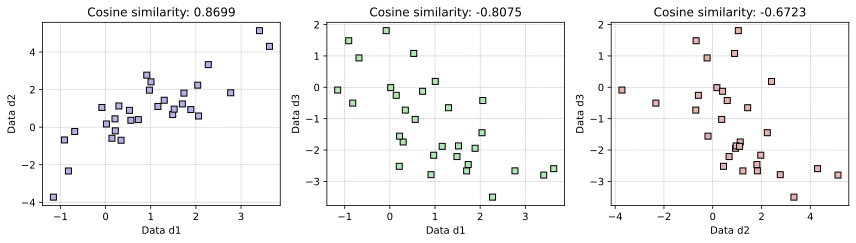

In [45]:
# cosine similarities
cs_d12 = torch.cosine_similarity(torch.tensor(d1).view(1,-1),torch.tensor(d2).view(1,-1))
cs_d13 = torch.cosine_similarity(torch.tensor(d1).view(1,-1),torch.tensor(d3).view(1,-1))
cs_d23 = torch.cosine_similarity(torch.tensor(d2).view(1,-1),torch.tensor(d3).view(1,-1))

# visualize
_,axs = plt.subplots(1,3,figsize=(12,3.5))
axs[0].plot(d1,d2,'ks',markerfacecolor=[.7,.7,.9])
axs[0].set(xlabel='Data d1',ylabel='Data d2',title=f'Cosine similarity: {cs_d12.item():.4f}')

axs[1].plot(d1,d3,'ks',markerfacecolor=[.7,.9,.7])
axs[1].set(xlabel='Data d1',ylabel='Data d3',title=f'Cosine similarity: {cs_d13.item():.4f}')

axs[2].plot(d2,d3,'ks',markerfacecolor=[.9,.7,.7])
axs[2].set(xlabel='Data d2',ylabel='Data d3',title=f'Cosine similarity: {cs_d23.item():.4f}')

for a in axs: a.grid(linestyle='--',linewidth=.5)

plt.tight_layout()
plt.show()